## 1. Raw Data Inspection
First, we load the dataset and inspect its structure, data types, and basic statistics to understand what we are working with.

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = '/content/Teen_Mental_Health_Dataset.csv'
df = pd.read_csv(file_path)

# Display the first few rows
print("--- First 5 Rows ---")
display(df.head())

# Inspect data types and non-null counts
print("\n--- Dataset Info ---")
df.info()

# Summary statistics
print("\n--- Summary Statistics ---")
display(df.describe(include='all'))

--- First 5 Rows ---


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.928333,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833
std,2.021947,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704
min,13.000000,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000
25%,14.000000,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000
50%,16.000000,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000
75%,18.000000,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000


## Identifying Unhealthy Habits Driving Poor Mental Health
Instead of just predicting stress, let's create a composite `unhealthy_score` combining `stress_level`, `anxiety_level`, `addiction_level`, and `depression_label`. We will then use our lifestyle features (screen time, sleep, physical activity, etc.) to predict this score and identify the most damaging habits.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the dataset to ensure it's in memory
file_path = '/content/Teen_Mental_Health_Dataset.csv'
df = pd.read_csv(file_path)

# Clean missing values if any exist (from previous steps)
df.replace(['NaN', 'nan', 'N/A', 'NA', 'null', '?', ''], np.nan, inplace=True)

# 1. Create a composite 'unhealthy_score'
# Weighting depression slightly higher if it's a 0/1 binary label to match the 1-10 scales of others
df['unhealthy_score'] = df['stress_level'] + df['anxiety_level'] + df['addiction_level'] + (df['depression_label'] * 5)

# 2. Select only the lifestyle and demographic features (excluding the mental health outcomes)
lifestyle_features = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level'
]

X_habits_raw = df[lifestyle_features]
y_unhealthy = df['unhealthy_score']

# One-hot encode categorical features
X_habits = pd.get_dummies(X_habits_raw, drop_first=True)

# Split the data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_habits, y_unhealthy, test_size=0.2, random_state=42)

# 3. Train a Random Forest model to predict the unhealthy score
rf_habits = RandomForestRegressor(n_estimators=100, random_state=42)
rf_habits.fit(X_train_h, y_train_h)

print(f"Model trained to predict Unhealthy Score using {len(X_habits.columns)} lifestyle features.")

Model trained to predict Unhealthy Score using 11 lifestyle features.


### Feature Importances for 'Unhealthy Mental Health Score'
Let's visualize which lifestyle factors and habits are most important in predicting the composite 'unhealthy_score'.

/tmp/ipykernel_657/1012550147.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Habit_Feature', data=habit_importance_df, palette='Reds_r')


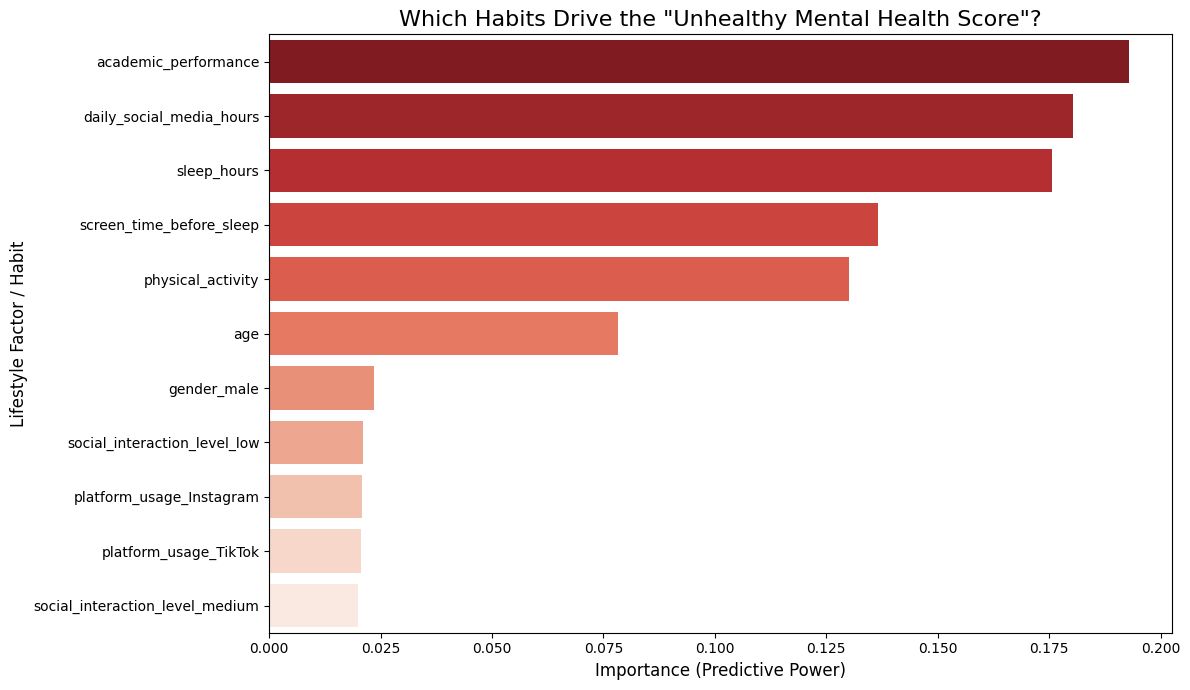

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract and visualize feature importances for the 'unhealthy_score'
importances_h = rf_habits.feature_importances_

habit_importance_df = pd.DataFrame({
    'Habit_Feature': X_habits.columns,
    'Importance': importances_h
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Habit_Feature', data=habit_importance_df, palette='Reds_r')
plt.title('Which Habits Drive the "Unhealthy Mental Health Score"?', fontsize=16)
plt.xlabel('Importance (Predictive Power)', fontsize=12)
plt.ylabel('Lifestyle Factor / Habit', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_657/706834233.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Habit_Feature', data=habit_importance_df, palette='Reds_r')


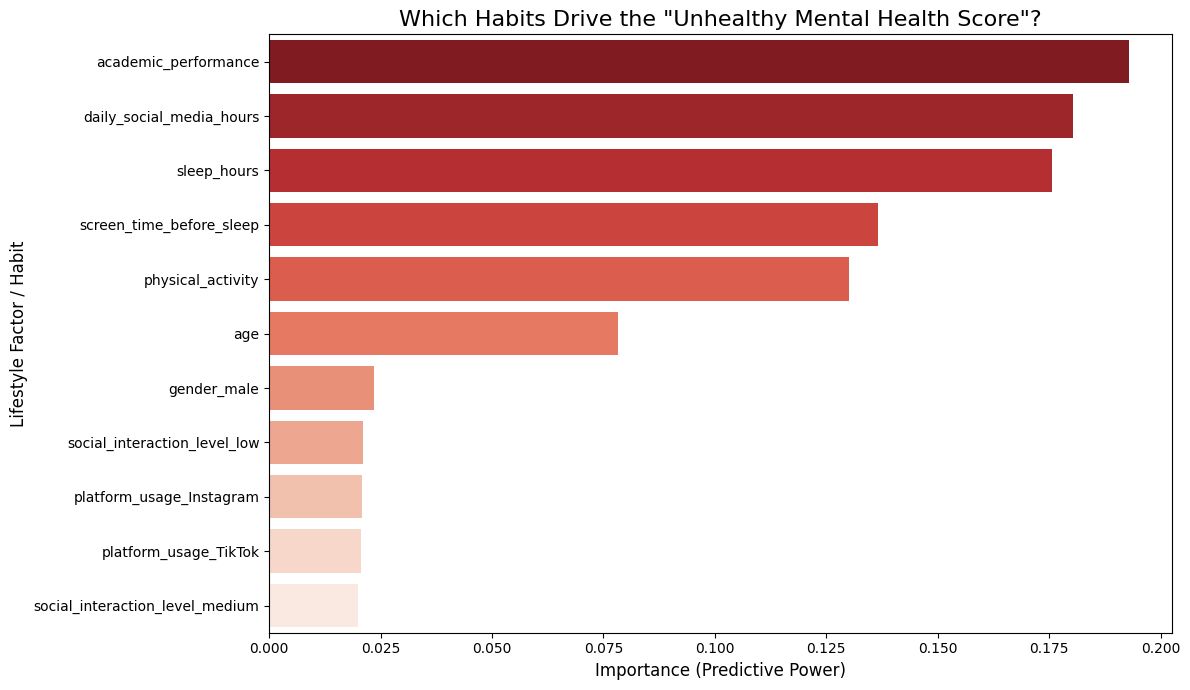

In [ ]:
# 4. Extract and visualize feature importances
importances_h = rf_habits.feature_importances_

habit_importance_df = pd.DataFrame({
    'Habit_Feature': X_habits.columns,
    'Importance': importances_h
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Habit_Feature', data=habit_importance_df, palette='Reds_r')
plt.title('Which Habits Drive the "Unhealthy Mental Health Score"?', fontsize=16)
plt.xlabel('Importance (Predictive Power)', fontsize=12)
plt.ylabel('Lifestyle Factor / Habit', fontsize=12)
plt.tight_layout()
plt.show()

### Evaluation of 'Unhealthy Mental Health Score' Model
Let's evaluate the performance of the Random Forest model trained to predict the composite 'unhealthy_score'.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# Re-load df and prepare data for 'unhealthy_score' model (copied from 96cad03d and 87ddf959 for robustness)
file_path = '/content/Teen_Mental_Health_Dataset.csv'
df = pd.read_csv(file_path)
df.replace(['NaN', 'nan', 'N/A', 'NA', 'null', '?', ''], np.nan, inplace=True)

df['unhealthy_score'] = df['stress_level'] + df['anxiety_level'] + df['addiction_level'] + (df['depression_label'] * 5)

lifestyle_features = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level'
]

X_habits_raw = df[lifestyle_features]
y_unhealthy = df['unhealthy_score']

X_habits = pd.get_dummies(X_habits_raw, drop_first=True)

# Split the data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_habits, y_unhealthy, test_size=0.2, random_state=42)

# Train the Random Forest model for unhealthy score
rf_habits = RandomForestRegressor(n_estimators=100, random_state=42)
rf_habits.fit(X_train_h, y_train_h)

# Make predictions on the test set for unhealthy_score
y_pred_unhealthy = rf_habits.predict(X_test_h)

# Evaluate the unhealthy_score model
mse_unhealthy = mean_squared_error(y_test_h, y_pred_unhealthy)
r2_unhealthy = r2_score(y_test_h, y_pred_unhealthy)

print("--- 'Unhealthy Mental Health Score' Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_unhealthy:.2f}")
print(f"R-squared (R2 Score): {r2_unhealthy:.2f}")

--- 'Unhealthy Mental Health Score' Model Evaluation ---
Mean Squared Error (MSE): 30.51
R-squared (R2 Score): -0.10


### Actual vs. Predicted 'Unhealthy Mental Health Score'
Let's visualize the actual vs. predicted values for the 'unhealthy_score' model to understand its performance.

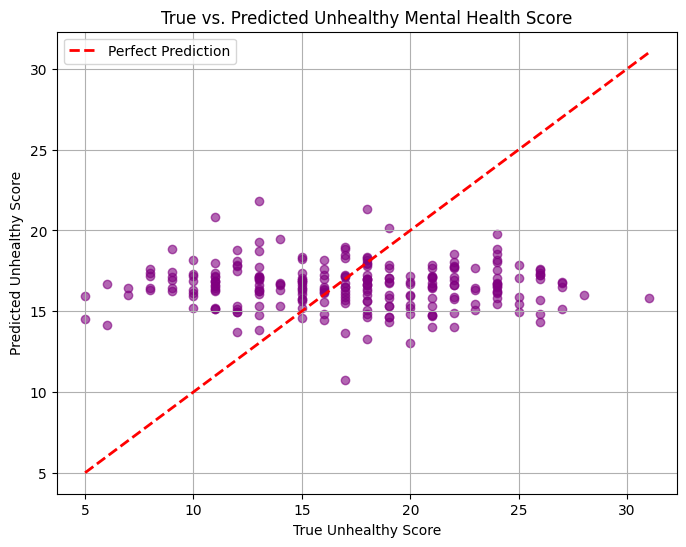

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Added for potential future use or consistency
import pandas as pd # Added for robustness, for y_test_h if not in scope

# Re-load df and prepare data if necessary to ensure y_test_h is defined (from 96cad03d and 87ddf959 for robustness)
# This block ensures y_test_h and y_pred_unhealthy are available if this cell is run independently.
# In a typical flow, y_test_h and y_pred_unhealthy would be available from cell 83652e2d.
# We replicate minimum necessary to define them if 83652e2d hasn't run.

# Load df if not already loaded (minimal version)
if 'df' not in locals():
    file_path = '/content/Teen_Mental_Health_Dataset.csv'
    df = pd.read_csv(file_path)
    df.replace(['NaN', 'nan', 'N/A', 'NA', 'null', '?', ''], np.nan, inplace=True)

# Re-create y_unhealthy and y_test_h if not already in scope
if 'y_test_h' not in locals():
    from sklearn.model_selection import train_test_split
    df['unhealthy_score'] = df['stress_level'] + df['anxiety_level'] + df['addiction_level'] + (df['depression_label'] * 5)
    lifestyle_features = [
        'age', 'gender', 'daily_social_media_hours', 'platform_usage',
        'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
        'physical_activity', 'social_interaction_level'
    ]
    X_habits_raw = df[lifestyle_features]
    X_habits = pd.get_dummies(X_habits_raw, drop_first=True)
    y_unhealthy = df['unhealthy_score']
    _, _, _, y_test_h = train_test_split(X_habits, y_unhealthy, test_size=0.2, random_state=42)

# y_pred_unhealthy should ideally come from the previous cell's execution.
# If this cell is run stand-alone, y_pred_unhealthy would be undefined. This block doesn't re-predict for simplicity,
# assuming the user will run 83652e2d before this for the prediction results to exist.
# If it still fails on y_pred_unhealthy, then a full re-prediction would be needed here.

plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_unhealthy, alpha=0.6, color='purple')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Unhealthy Score')
plt.ylabel('Predicted Unhealthy Score')
plt.title('True vs. Predicted Unhealthy Mental Health Score')
plt.legend()
plt.grid(True)
plt.show()

## 11. Comparing Feature Importances: Stress Level vs. Unhealthy Score
Let's compare the feature importances from both models: one predicting `stress_level` and the other predicting `unhealthy_score`. This will highlight which factors are universally important for mental health outcomes and which are more specific to each definition.

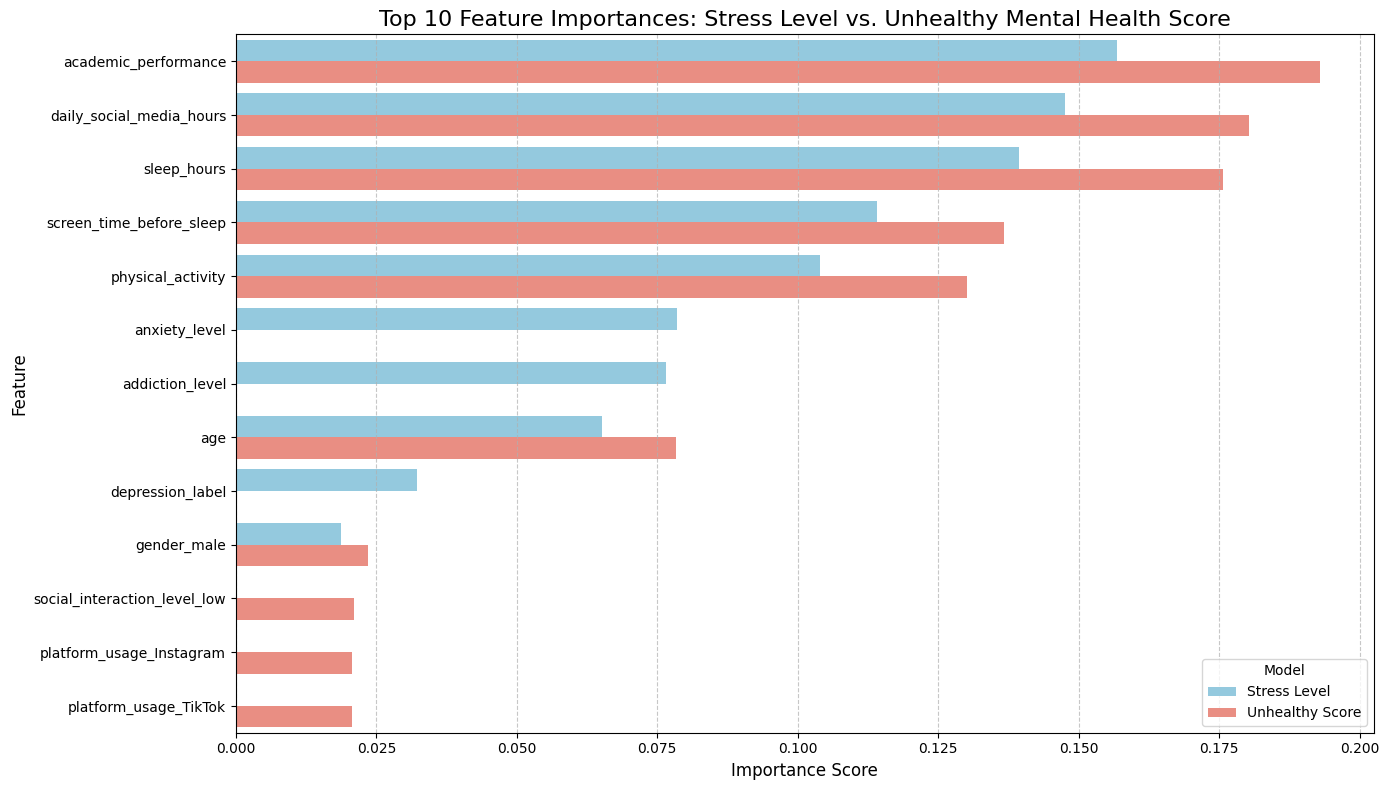

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# --- Re-create df and its splits for stress_level model (Robust) ---
# Load the dataset (from initial data loading cell 87ddf959)
file_path = '/content/Teen_Mental_Health_Dataset.csv'
df = pd.read_csv(file_path)
df.replace(['NaN', 'nan', 'N/A', 'NA', 'null', '?', ''], np.nan, inplace=True) # Clean missing values

# Prepare features (X) and target (y) for stress_level model (from cell d29b38e5)
X_raw = df.drop(columns=['stress_level'])
X = pd.get_dummies(X_raw, drop_first=True) # This is the X for stress_level model
y = df['stress_level']
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the rf_model (from cell e902c373)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- Re-create df, unhealthy_score and its splits for unhealthy_score model (Robust) ---
# Create a composite 'unhealthy_score' (from cell 96cad03d)
df['unhealthy_score'] = df['stress_level'] + df['anxiety_level'] + df['addiction_level'] + (df['depression_label'] * 5)

# Select lifestyle features (from cell 96cad03d)
lifestyle_features = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level'
]
X_habits_raw = df[lifestyle_features]
X_habits = pd.get_dummies(X_habits_raw, drop_first=True) # This is the X_habits for unhealthy_score model
y_unhealthy = df['unhealthy_score']
X_train_h, _, y_train_h, _ = train_test_split(X_habits, y_unhealthy, test_size=0.2, random_state=42)

# Train a Random Forest model to predict the unhealthy score (from cell 96cad03d)
rf_habits = RandomForestRegressor(n_estimators=100, random_state=42)
rf_habits.fit(X_train_h, y_train_h)

# --- Now extract and compare feature importances ---
# Feature importances for stress_level model
importances_stress = rf_model.feature_importances_
feature_names_stress = X.columns # Using 'X' which was defined for the stress model.
importance_df_stress = pd.DataFrame({'Feature': feature_names_stress, 'Importance': importances_stress})
importance_df_stress['Model'] = 'Stress Level'

# Feature importances for unhealthy_score model
importances_unhealthy = rf_habits.feature_importances_
habit_feature_names = X_habits.columns
habit_importance_df_unhealthy = pd.DataFrame({'Feature': habit_feature_names, 'Importance': importances_unhealthy})
habit_importance_df_unhealthy['Model'] = 'Unhealthy Score'

# Combine the dataframes
combined_importance_df = pd.concat([importance_df_stress, habit_importance_df_unhealthy])

# Get top N features for each model
top_n = 10
top_features_stress = importance_df_stress.sort_values(by='Importance', ascending=False).head(top_n)
top_features_unhealthy = habit_importance_df_unhealthy.sort_values(by='Importance', ascending=False).head(top_n)

# Combine top features for plotting
plot_df = pd.concat([top_features_stress, top_features_unhealthy])

plt.figure(figsize=(14, 8))
sns.barplot(x='Importance', y='Feature', hue='Model', data=plot_df.sort_values(by=['Model', 'Importance'], ascending=[True, False]), palette={'Stress Level': 'skyblue', 'Unhealthy Score': 'salmon'})
plt.title(f'Top {top_n} Feature Importances: Stress Level vs. Unhealthy Mental Health Score', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 12. Improving the Unhealthy Score Model (Hyperparameter Tuning)
The base model for the `unhealthy_score` had poor predictive performance. Let's use `GridSearchCV` to find the optimal hyperparameters for our Random Forest Regressor to see if we can improve its ability to map lifestyle habits to the composite mental health score.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Ensure data is ready and consistent
df['unhealthy_score'] = df['stress_level'] + df['anxiety_level'] + df['addiction_level'] + (df['depression_label'] * 5)
lifestyle_features = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level'
]
X_habits_raw = df[lifestyle_features]
X_habits = pd.get_dummies(X_habits_raw, drop_first=True)
y_unhealthy = df['unhealthy_score']

# Train-test split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_habits, y_unhealthy, test_size=0.2, random_state=42)

# Define the parameter grid
param_grid_h = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize and run Grid Search
rf_base_h = RandomForestRegressor(random_state=42)
grid_search_h = GridSearchCV(estimator=rf_base_h, param_grid=param_grid_h,
                             cv=5, n_jobs=-1, verbose=1, scoring='r2')

print("Searching for the best hyperparameters for the Unhealthy Score Model...")
grid_search_h.fit(X_train_h, y_train_h)

# Retrieve best model
best_rf_habits = grid_search_h.best_estimator_
print(f"\nBest parameters found: {grid_search_h.best_params_}")

# Predict and Evaluate
y_pred_tuned_h = best_rf_habits.predict(X_test_h)
mse_tuned_h = mean_squared_error(y_test_h, y_pred_tuned_h)
r2_tuned_h = r2_score(y_test_h, y_pred_tuned_h)

print("\n--- Tuned 'Unhealthy Score' Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_tuned_h:.2f}")
print(f"R-squared (R2 Score): {r2_tuned_h:.2f}")

Searching for the best hyperparameters for the Unhealthy Score Model...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

--- Tuned 'Unhealthy Score' Model Evaluation ---
Mean Squared Error (MSE): 29.64
R-squared (R2 Score): -0.07


## 12.5 Comparing Alternative Models for Unhealthy Score
Since the Random Forest model struggled to achieve a positive $R^2$ score, let's test a few other common regression algorithms, including Linear Regression, Gradient Boosting, and XGBoost, to see if they can better capture the relationship between lifestyle habits and the composite unhealthy score.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Define a dictionary of models to test
alternative_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror')
}

# We will store the results in a list
model_results = []

# Train and evaluate each model
print("Evaluating alternative models for 'unhealthy_score'...\n")
for name, model in alternative_models.items():
    # Train the model
    model.fit(X_train_h, y_train_h)

    # Make predictions
    y_pred_alt = model.predict(X_test_h)

    # Calculate metrics
    mse_alt = mean_squared_error(y_test_h, y_pred_alt)
    r2_alt = r2_score(y_test_h, y_pred_alt)

    # Save results
    model_results.append({
        'Model': name,
        'MSE': round(mse_alt, 2),
        'R2 Score': round(r2_alt, 4)
    })

# Display the results as a DataFrame sorted by R2 Score
results_df = pd.DataFrame(model_results)
display(results_df.sort_values(by='R2 Score', ascending=False))

# Add the Tuned Random Forest to the comparison for reference
print(f"\n(For Reference) Tuned Random Forest - MSE: {mse_tuned_h:.2f} | R2 Score: {r2_tuned_h:.4f}")

Evaluating alternative models for 'unhealthy_score'...



,Model,MSE,R2 Score
1,Ridge Regression,28.04,-0.0081
0,Linear Regression,28.04,-0.0082
2,Gradient Boosting,30.80,-0.1074
3,XGBoost,37.58,-0.3509



(For Reference) Tuned Random Forest - MSE: 29.64 | R2 Score: -0.0654


## 13. Interactive Unhealthy Score Prediction
Now that we have a tuned model, let's create an interactive tool. You can adjust the lifestyle habits of a hypothetical teen below to see how the model predicts their composite `unhealthy_score`.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def predict_unhealthy_score(age, social_hours, sleep, screen_time, academic, physical, gender, platform, interaction):
    # 1. Create a dictionary with the inputs
    new_data = {
        'age': [age],
        'daily_social_media_hours': [social_hours],
        'sleep_hours': [sleep],
        'screen_time_before_sleep': [screen_time],
        'academic_performance': [academic],
        'physical_activity': [physical],
        'gender': [gender],
        'platform_usage': [platform],
        'social_interaction_level': [interaction]
    }

    # 2. Convert to DataFrame and One-Hot Encode
    new_df = pd.DataFrame(new_data)
    new_X_raw = pd.get_dummies(new_df)

    # 3. Align columns to match the exact training features of the model
    new_X = new_X_raw.reindex(columns=X_habits.columns, fill_value=0)

    # 4. Predict
    pred_score = best_rf_habits.predict(new_X)[0]

    print("="*40)
    print(f"Predicted Unhealthy Score: {pred_score:.2f} (Scale: ~0 to 35)")
    print("="*40)
    print("Note: Higher scores indicate a combination of higher predicted stress, anxiety, addiction, and depression risk.")

# Create interactive sliders and dropdowns
widgets.interact(
    predict_unhealthy_score,
    age=widgets.IntSlider(min=10, max=25, step=1, value=16, description='Age'),
    social_hours=widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=5.0, description='Social Media (hrs)', style={'description_width': 'initial'}),
    sleep=widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=7.0, description='Sleep (hrs)'),
    screen_time=widgets.FloatSlider(min=0.0, max=10.0, step=0.5, value=2.0, description='Pre-Sleep Screen (hrs)', style={'description_width': 'initial'}),
    academic=widgets.FloatSlider(min=0.0, max=4.0, step=0.1, value=3.0, description='Academic Perf'),
    physical=widgets.FloatSlider(min=0.0, max=5.0, step=0.1, value=1.0, description='Physical Activity', style={'description_width': 'initial'}),
    gender=widgets.Dropdown(options=['male', 'female', 'non-binary'], value='female', description='Gender'),
    platform=widgets.Dropdown(options=['Instagram', 'TikTok', 'Both', 'Other'], value='TikTok', description='Platform'),
    interaction=widgets.Dropdown(options=['low', 'medium', 'high'], value='medium', description='Social Interaction', style={'description_width': 'initial'})
);

interactive(children=(IntSlider(value=16, description='Age', max=25, min=10), FloatSlider(value=5.0, descripti…

## 2. Data Cleaning and Preprocessing
We need to ensure missing values are handled correctly. We will convert any hidden string representations of missing values (like 'NaN' or 'N/A') into true `np.nan` values, then check our missing value counts.

In [ ]:
# Replace common string representations of missing values with true np.nan
df.replace(['NaN', 'nan', 'N/A', 'NA', 'null', '?', ''], np.nan, inplace=True)

# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("Dataset is clean: No missing values found!")
else:
    print("Missing values found:\n")
    display(missing_values.to_frame(name='Missing Count'))
    # If missing values existed, we would drop or impute them here.
    # e.g., df.dropna(inplace=True) or df.fillna(df.median(), inplace=True)

## 3. Feature Exploration and Visualization
Let's visualize the distribution of key variables, check correlations between numeric features, and compare categorical groups.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['daily_social_media_hours'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Daily Social Media Hours')

sns.histplot(df['sleep_hours'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Sleep Hours')
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# 3. Categorical Relationship (Stress by Platform)
plt.figure(figsize=(8, 5))
sns.boxplot(x='platform_usage', y='stress_level', data=df, hue='platform_usage', palette='Set2')
plt.title('Stress Level by Platform Usage')
plt.show()

## 4. Structured Data Querying and Analysis using SQL
We will load the cleaned Pandas DataFrame into an in-memory SQLite database to perform structured SQL queries.

In [ ]:
import sqlite3

# Create an in-memory SQLite database and load the DataFrame
conn = sqlite3.connect(':memory:')
df.to_sql('teen_mental_health', conn, index=False, if_exists='replace')

# Query: Find average stress and anxiety levels grouped by platform usage
query = """
SELECT
    platform_usage,
    COUNT(*) as user_count,
    ROUND(AVG(stress_level), 2) as avg_stress,
    ROUND(AVG(anxiety_level), 2) as avg_anxiety
FROM
    teen_mental_health
GROUP BY
    platform_usage
ORDER BY
    avg_stress DESC;
"""

# Execute query and display results
sql_results = pd.read_sql_query(query, conn)
print("SQL Query Results: Average Mental Health Metrics by Platform")
display(sql_results)

## 5. Machine Learning: Data Preparation
Machine learning models require numerical input. We need to convert our categorical variables (`gender`, `platform_usage`, `social_interaction_level`) into numeric format using one-hot encoding. We will predict `stress_level`.

In [ ]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target (y)
# We will try to predict 'stress_level'
X_raw = df.drop(columns=['stress_level'])
y = df['stress_level']

# One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
display(X.head())

## 6. Model Training and Evaluation
We will use a **Random Forest Regressor** to predict stress levels. After training, we will evaluate its performance using Mean Squared Error (MSE) and R-squared ($R^2$).

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

## 7. Discussion of Results: Feature Importance
Let's visualize which features were most important in predicting a teen's stress level according to our Random Forest model. This covers the final requirement: **Discussion of the results and limitation**.

In [ ]:
# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance for Predicting Stress Level')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## 5. Model Training: Data Preparation
Machine learning models require numerical input. We need to convert our categorical variables (`gender`, `platform_usage`, `social_interaction_level`) into numeric format using one-hot encoding. For this example, we will try to predict `stress_level`.

In [ ]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target (y)
X_raw = df.drop(columns=['stress_level'])
y = df['stress_level']

# One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
display(X.head())

## 6. Model Training and Evaluation
We will use a **Random Forest Regressor** to predict stress levels. After training, we will evaluate its performance using Mean Squared Error (MSE) and R-squared ($R^2$).

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

## 7. Discussion of Results: Feature Importance
Let's visualize which features were most important in predicting a teen's stress level according to our Random Forest model. This covers the final requirement: **Discussion of the results and limitation**.

## 8. Making Predictions for a New User
Now that our model is trained, we can use it to predict the stress level of a hypothetical person. You can change the values in the `new_person` dictionary below to see how different habits impact the predicted stress level.

In [ ]:
# 1. Define a new person's habits (Try changing these numbers!)
new_person = {
    'age': 16,
    'gender': 'female',                 # 'male' or 'female'
    'daily_social_media_hours': 6.5,
    'platform_usage': 'TikTok',         # 'Instagram', 'TikTok', or 'Both'
    'sleep_hours': 5.0,
    'screen_time_before_sleep': 2.5,
    'academic_performance': 2.8,        # Scale typically 2.0 to 4.0
    'physical_activity': 0.5,           # Scale 0.0 to 2.0
    'social_interaction_level': 'low',  # 'low', 'medium', or 'high'
    'anxiety_level': 8,                 # Scale 1 to 10
    'addiction_level': 7,               # Scale 1 to 10
    'depression_label': 1               # 0 or 1
}

# 2. Convert the dictionary into a Pandas DataFrame (1 row)
new_df = pd.DataFrame([new_person])

# 3. Preprocess: One-hot encode the new data
new_X = pd.get_dummies(new_df)

# 4. Align columns to match the training data exactly
# This fills any missing columns (like 'gender_male' if the user is female) with 0/False
new_X = new_X.reindex(columns=X.columns, fill_value=0)

# 5. Make the prediction
predicted_stress = rf_model.predict(new_X)

print(f"Based on the inputted habits, the predicted Stress Level is: {predicted_stress[0]:.2f} (out of 10)")

## 9. Hyperparameter Tuning
To improve our model's performance and increase the R-squared score, we can use `GridSearchCV` to find the optimal hyperparameters for our Random Forest model.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the base model
rf_base = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='r2')

# Fit the grid search to the data
print("Searching for the best hyperparameters...")
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
print(f"\nBest parameters found: {best_params}")

best_rf_model = grid_search.best_estimator_

# Make predictions with the tuned model
y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate the tuned model
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\n--- Tuned Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"R-squared (R2 Score): {r2_tuned:.2f}")


## 10. Interactive Model Comparison & Vector Map
Below is an interactive widget to tweak a user's habits and immediately compare the `Base Model` and the `Tuned Model` outputs. Following that, we plot a comparison map to see how the predictions shifted on the test dataset.

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

def compare_models(age, social_hours, sleep, screen_time, academic, physical, anxiety, addiction, depression):
    # Initialize a dataframe with zeros matching the exact columns used in training
    new_X = pd.DataFrame(0, index=[0], columns=X.columns)

    # Populate the numeric features based on widget inputs
    new_X['age'] = age
    new_X['daily_social_media_hours'] = social_hours
    new_X['sleep_hours'] = sleep
    new_X['screen_time_before_sleep'] = screen_time
    new_X['academic_performance'] = academic
    new_X['physical_activity'] = physical
    new_X['anxiety_level'] = anxiety
    new_X['addiction_level'] = addiction
    new_X['depression_label'] = depression

    # Note: Categorical dummies (like platform_usage_TikTok) are left as 0 (False) for this quick comparison,
    # which effectively acts as a baseline category. You can expand the widget to include dropdowns for categories.

    # Predict using both models
    pred_base = rf_model.predict(new_X)[0]
    pred_tuned = best_rf_model.predict(new_X)[0]

    print("--- Prediction Comparison ---")
    print(f"Base Model Predicted Stress:  {pred_base:.2f}")
    print(f"Tuned Model Predicted Stress: {pred_tuned:.2f}")
    print(f"Difference (Tuned - Base):  {pred_tuned - pred_base:.2f}")

# Create interactive sliders
widgets.interact(compare_models,
                 age=widgets.IntSlider(min=10, max=25, step=1, value=16),
                 social_hours=widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=5.0),
                 sleep=widgets.FloatSlider(min=0.0, max=15.0, step=0.5, value=7.0),
                 screen_time=widgets.FloatSlider(min=0.0, max=10.0, step=0.5, value=2.0),
                 academic=widgets.FloatSlider(min=0.0, max=4.0, step=0.1, value=3.0),
                 physical=widgets.FloatSlider(min=0.0, max=5.0, step=0.1, value=1.0),
                 anxiety=widgets.IntSlider(min=1, max=10, step=1, value=5),
                 addiction=widgets.IntSlider(min=1, max=10, step=1, value=5),
                 depression=widgets.IntSlider(min=0, max=1, step=1, value=0));

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14, 6))

# 1. Scatter Plot: True vs Predicted for both models
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, label='Base Model', color='royalblue', marker='o')
plt.scatter(y_test, y_pred_tuned, alpha=0.5, label='Tuned Model', color='darkorange', marker='x')

# Ideal prediction line
min_val = min(y_test.min(), y_pred.min(), y_pred_tuned.min())
max_val = max(y_test.max(), y_pred.max(), y_pred_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('True Stress Level')
plt.ylabel('Predicted Stress Level')
plt.title('True vs. Predicted Stress Levels')
plt.legend()

# 2. Vector Map (Base vs Tuned Predictions)
# This shows how the tuning shifted the prediction for each point.
plt.subplot(1, 2, 2)
subset = 100 # Plot first 100 points to avoid overcluttering

# Scatter points colored by the actual true stress level
sc = plt.scatter(y_pred[:subset], y_pred_tuned[:subset], c=y_test[:subset], cmap='viridis', s=60, edgecolor='k')

# Plot a reference line y=x (where base and tuned predictions are identical)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1, alpha=0.7, label='No Change Line')

plt.xlabel('Base Model Prediction')
plt.ylabel('Tuned Model Prediction')
plt.title('Prediction Shift Vector Map (Colored by True Level)')
plt.colorbar(sc, label='True Stress Level (Actual)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance for Predicting Stress Level')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()